In [9]:
x_0=-0.5
x_1=0.5
h1=1
m=0.5
import numpy as np                                                        #  matrix coupling
def coupling(matrix_1,matrix_2):                                 
    s11_1=matrix_1[0][0]
    s12_1=matrix_1[0][1]
    s21_1=matrix_1[1][0]
    s22_1=matrix_1[1][1]
    s11_2=matrix_2[0][0]
    s12_2=matrix_2[0][1]
    s21_2=matrix_2[1][0]
    s22_2=matrix_2[1][1]
    s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
    s12=s12_1*s12_2/(1-s11_2*s22_1)
    s21=s21_2*s21_1/(1-s11_2*s22_1)
    s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)
    result = np.array([[s11, s12], [s21, s22]], np.complex128)
    return result                                                   
def multiple_coupling(matrix_collect_1):                                  #  multiple_coupling
    matrix_collect_2= matrix_collect_1[0]
    for i in np.arange(len(matrix_collect_1)):
        if i==len(matrix_collect_1)-1:
            break
        matrix_collect_2=coupling(matrix_collect_2,matrix_collect_1[i+1])
    return matrix_collect_2

def coupling_matrix_of_N_modified(E,y1,y2,N,n3,n4):     #coupling_matrix_of_N    N is period  (n3 is +)  (n3 is -)
    constant_1=2*m*(y1+1j*y2)/(h1**2)
    constant_2=2*m*(y1-1j*y2)/(h1**2)
    di=np.zeros((2*N+n3+n4),dtype=complex)
    for i in np.arange(2*N+n3+n4):
        if i<(2*N):
            if i%2==0:
                di[i]=constant_1
            if i%2==1:
                di[i]=constant_2
        if i>=(2*N) and i<(2*N+n3):
            di[i]=constant_1
        if i>=(2*N+n3):
            di[i]=constant_2
#    print(di)

    location = np.linspace(x_0, x_1, 2*N+n3+n4)          #n4 is (Sum of Plus first potential)
    k=(E*2*m)**0.5/(h1)
    matrix_collect = np.zeros((2*N+n3+n4, 2, 2), dtype=complex)
    for i in np.arange(2*N+n3+n4):
        s11=di[i]*np.exp((2j)*k*location[i])
        s12=2j*k
        s21=2j*k
        s22=di[i]*np.exp((-2j)*k*location[i])
        if i==len(np.arange(2*N+n3+n4))-1:
            s12=0
            s22=0
        matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
        matrix_collect[i]=matrix_3
    matrix_6 = multiple_coupling(matrix_collect)
#    print(matrix_collect)
  #  print(matrix_6)
    return matrix_6
def Transmission_coefficient_of_N_modified(E,y1,y2,N,n3,n4):
    return float(abs(coupling_matrix_of_N_modified(E,y1,y2,N,n3,n4)[1][0]**2))
def Reflection_coefficient_of_N_modified(E,y1,y2,N,n3,n4):
    return float(abs(coupling_matrix_of_N_modified(E,y1,y2,N,n3,n4)[0][0]**2))

In [13]:
x_0=0
x_1=1
h1=1
m=0.5
E=1
N=1
n3=0
n4=0
y1=1
y2=0
print('T:',Transmission_coefficient_of_N_modified(E,y1,y2,N,n3,n4))

T: 0.5198603146522006


In [14]:
E=1
N=3
n3=0
n4=0
y1=2
y2=0
print('T:',Transmission_coefficient_of_N_modified(E,y1,y2,N,n3,n4))#,'R:',Reflection_coefficient_of_N_modified(E,y1,y2,N,n3,n4))
print(abs(-0.69088665+0.15058434j)**2,abs(-0.58936795-0.39069862j)**2)

T: 0.001322378380655768
0.5000000066014583 0.4999999921571069


In [16]:
#AI
import numpy as np

# 定义初始矩阵
C1 = np.array([[-0.69088665 + 0.15058434j, 0.5 - 0.5j],
               [0.5 - 0.5j, 0.15058434 - 0.69088665j]])

C2 = np.array([[-0.69498904 - 0.13034657j, 0.5 - 0.5j],
               [0.5 - 0.5j, -0.13034657 - 0.69498904j]])

C3 = np.array([[-0.58936795 - 0.39069862j, 0.5 - 0.5j],
               [0.5 - 0.5j, -0.39069862 - 0.58936795j]])

C4 = np.array([[-0.39069862 - 0.58936795j, 0.5 - 0.5j],
               [0.5 - 0.5j, -0.58936795 - 0.39069862j]])

C5 = np.array([[-0.13034657 - 0.69498904j, 0.5 - 0.5j],
               [0.5 - 0.5j, -0.69498904 - 0.13034657j]])

C6 = np.array([[0.15058434 - 0.69088665j, -0.0 - 0.0j],
               [0.5 - 0.5j, -0.0 - 0.0j]])

# 定义耦合函数
def couple_matrices(C1, C2):
    C1_11, C1_12 = C1[0, 0], C1[0, 1]
    C1_21, C1_22 = C1[1, 0], C1[1, 1]
    C2_11, C2_12 = C2[0, 0], C2[0, 1]
    C2_21, C2_22 = C2[1, 0], C2[1, 1]

    denominator = 1 - C2_11 * C1_22

    C_11 = C1_11 + C1_12 * C2_11 * C1_21 / denominator
    C_12 = C1_12 * C2_12 / denominator
    C_21 = C2_21 * C1_21 / denominator
    C_22 = C2_22 + C2_21 * C1_22 * C2_12 / denominator

    return np.array([[C_11, C_12], [C_21, C_22]])

# 依次耦合矩阵
C = couple_matrices(C1, C2)
C = couple_matrices(C, C3)
C = couple_matrices(C, C4)
C = couple_matrices(C, C5)
C = couple_matrices(C, C6)

# 输出最终结果
print("最终的耦合矩阵 C:")
print(C)

最终的耦合矩阵 C:
[[-0.86461251+0.50112158j  0.        +0.j        ]
 [-0.01823511-0.03146203j  0.        +0.j        ]]


In [ ]:
E=20
N=100
n3=0
n4=0
y1=1
y2=0
print(Transmission_coefficient_of_N_modified(E,y1,y2,N,n3,n4),Reflection_coefficient_of_N_modified(E,y1,y2,N,n3,n4),Transmission_coefficient_of_N_modified(E,y1,y2,N,n3,n4)+Reflection_coefficient_of_N_modified(E,y1,y2,N,n3,n4))

3.04888463246754e-12 0.9999999999969463 0.9999999999999952


In [ ]:
E=20
N=100
n3=0
n4=0
y1=0
y2=-2j
print(Transmission_coefficient_of_N_modified(E,y1,y2,N,n3,n4),Reflection_coefficient_of_N_modified(E,y1,y2,N,n3,n4))

0.9528724189770371 0.04712758102298324


In [ ]:
E=20
N=200
y=2
k=(2*m*E/(h1**2))**0.5                                           
constant_1=2*m*y/(h1**2)
print(Transmission_coefficient_of_N(N),Reflection_coefficient_of_N(N))

0.9528724189770371 0.04712758102298324


In [ ]:
x_0=-0.5
x_1=0.5
h1=1
m=0.5
import numpy as np                                                        #  matrix coupling
def coupling(matrix_1,matrix_2):                                 
    s11_1=matrix_1[0][0]
    s12_1=matrix_1[0][1]
    s21_1=matrix_1[1][0]
    s22_1=matrix_1[1][1]
    s11_2=matrix_2[0][0]
    s12_2=matrix_2[0][1]
    s21_2=matrix_2[1][0]
    s22_2=matrix_2[1][1]
    s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
    s12=s12_1*s12_2/(1-s11_2*s22_1)
    s21=s21_2*s21_1/(1-s11_2*s22_1)
    s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)
    result = np.array([[s11, s12], [s21, s22]], np.complex128)
    return result                                                   
def multiple_coupling(matrix_collect_1):                                  #  multiple_coupling
    matrix_collect_2= matrix_collect_1[0]
    for i in np.arange(len(matrix_collect_1)):
        if i==len(matrix_collect_1)-1:
            break
        matrix_collect_2=coupling(matrix_collect_2,matrix_collect_1[i+1])
    return matrix_collect_2


def coupling_matrix_of_N(N):                                              #coupling_matrix_of_N
    location = np.linspace(x_0, x_1, N)
    di=np.zeros((N),dtype=complex)
    for i in np.arange(N):
        di[i]=constant_1*(-1)**(i) 
    matrix_collect = np.zeros((N, 2, 2), dtype=complex)
    for i in np.arange(N):
        s11=di[i]*np.exp((2j)*k*location[i])
        s12=2j*k
        s21=2j*k
        s22=di[i]*np.exp((-2j)*k*location[i])
        if i==len(np.arange(N))-1:
            s12=0
            s22=0
        matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
        matrix_collect[i]=matrix_3
    matrix_6 = multiple_coupling(matrix_collect)
 #   print(di)
    return matrix_6
def Transmission_coefficient_of_N(N):
    return float(abs(coupling_matrix_of_N(N)[1][0]**2))
def Reflection_coefficient_of_N(N):
    return float(abs(coupling_matrix_of_N(N)[0][0]**2))

In [ ]:
import numpy as np    
E = np.linspace(0,300,500)
y1= E**2
y2=(E+1)**2+1+2*(E-1)*np.cos(2*E**0.5)+2*E**2*np.sin(2*E**0.5)
y3=y1/y2

C:\Users\taoji\AppData\Local\Temp\ipykernel_16616\2075124707.py:5: RuntimeWarning: invalid value encountered in divide
  y3=y1/y2


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


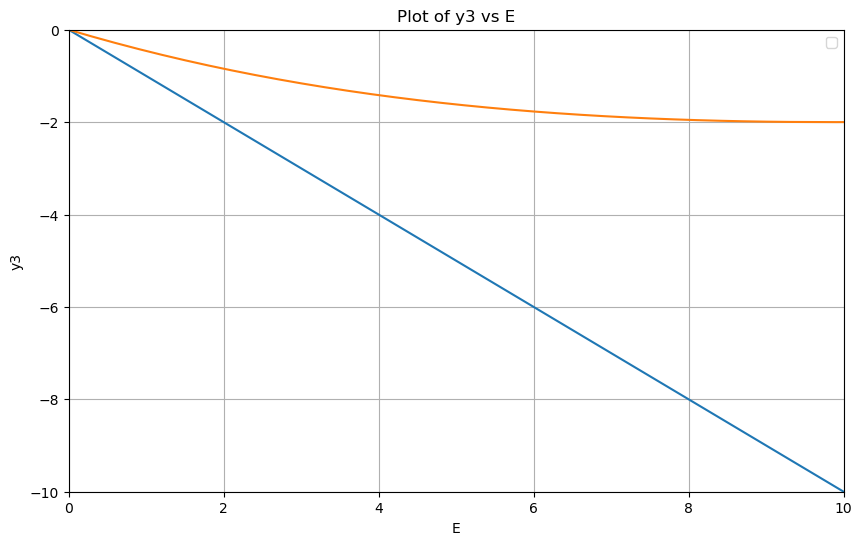

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定义 E 的范围
E = np.linspace(0, 300, 1000)

# 计算 y1, y2, y3
y1 = -E
y2 = np.cos(E**0.5)-1
# 绘制图形
plt.figure(figsize=(10, 6))  # 设置图形大小
plt.plot(E, y1) # 绘制 E 和 y3 的关系
plt.plot(E, y2) # 绘制 E 和 y3 的关系
plt.xlabel('E')  # x 轴标签
plt.ylabel('y3')  # y 轴标签
plt.title('Plot of y3 vs E')  # 图形标题
plt.xlim(0,10)
plt.ylim(-10,0)
plt.grid(True)  # 添加网格
plt.legend()  # 显示图例
plt.show()  # 显示图形

C:\Users\taoji\AppData\Local\Temp\ipykernel_7116\3999522539.py:9: RuntimeWarning: invalid value encountered in divide
  y2 = np.cos(E**0.5)+d1*np.sin(E**0.5)/E**0.5-(d1**2+d2**2)*(np.cos(E**0.5)-1)/(4*E)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


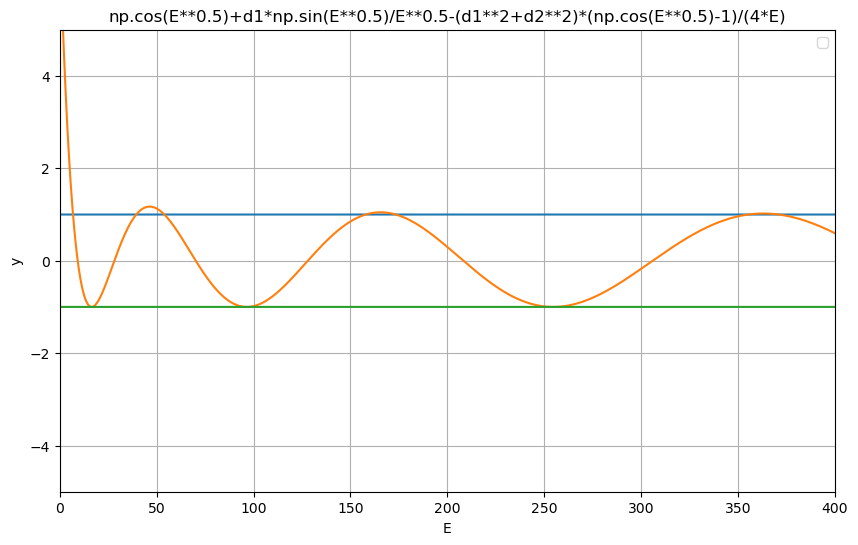

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
d1=4
d2=0

E = np.linspace(0, 400, 10000)
y1=np.zeros((len(E)))
y1[:] = 1
y2 = np.cos(E**0.5)+d1*np.sin(E**0.5)/E**0.5-(d1**2+d2**2)*(np.cos(E**0.5)-1)/(4*E)
y3=np.zeros((len(E)))
y3[:]= -1
plt.figure(figsize=(10, 6))  # 设置图形大小
plt.plot(E, y1) 
plt.plot(E, y2) 
plt.plot(E, y3)
plt.xlabel('E')  # x 轴标签
plt.ylabel('y')  # y 轴标签
plt.title('np.cos(E**0.5)+d1*np.sin(E**0.5)/E**0.5-(d1**2+d2**2)*(np.cos(E**0.5)-1)/(4*E)')  # 图形标题
plt.xlim(0,400)
plt.ylim(-5,5)
plt.grid(True)  # 添加网格
plt.legend()  # 显示图例
plt.show()  # 显示图形

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
del y2
z = np.linspace(-5*np.pi, 5*np.pi, 1000)
y1=np.zeros((len(z)))
y1[:] = 1
y2 = np.cos(z)+10*np.sin(z)/z
y3=np.zeros((len(z)))
y3[:]= -1
plt.figure(figsize=(10, 6))  # 设置图形大小
plt.plot(z, y1) 
plt.plot(z, y2) 
plt.plot(z, y3)
plt.xlabel('E')  # x 轴标签
plt.ylabel('y')  # y 轴标签
plt.title('Plot of y vs E')  # 图形标题
plt.xlim(-5*np.pi,5*np.pi)
plt.ylim(-5,5)
plt.grid(True)  # 添加网格
plt.legend()  # 显示图例
plt.show()  # 显示图形

NameError: name 'y2' is not defined

In [ ]:
z=np.pi
np.cos(z)+10*np.sin(z)/z

-0.9999999999999996

In [ ]:
def calculate_energy_levels(N, y1, y2, a, E_min, E_max, tol=1e-6):
    """
    计算给定参数下的能量级别(E值)
    参数:
        N: 系统参数
        y1, y2: 势能参数
        a: 系统参数
        E_min, E_max: 能量范围
        tol: 容差
    返回:
        排序后的唯一E值列表
    """
    N_0 = N if N % 2 == 0 else N - 1
    n_values = np.arange(int(N_0/2 + 1))
    E_sym = symbols('E')
    all_solutions = []

    for n in n_values:
        equation = cos(2 * a * sqrt(E_sym)) + y1 * sin(2 * a * sqrt(E_sym)) / sqrt(E_sym) \
                   - (y1**2 + y2**2) * (cos(2 * a * sqrt(E_sym)) - 1) / (4 * E_sym) \
                   - cos(2 * pi * n / N)
        
        solutions = []
        for E_guess in np.linspace(E_min + 0.1, E_max, 100):
            try:
                sol = nsolve(equation, E_guess, tol=1e-6)
                if E_min <= sol <= E_max:
                    is_new = True
                    for existing in solutions:
                        if abs(existing - sol) < tol:
                            is_new = False
                            break
                    if is_new:
                        solutions.append(float(sol))
            except:
                continue
        
        solutions.sort()
        all_solutions.extend(solutions)

    return sorted(list(set(round(sol/tol)*tol for sol in all_solutions)))

In [ ]:
import numpy as np
import os
from PIL import Image, ImageDraw, ImageFont
import imageio
from sympy import symbols, nsolve, cos, sin, sqrt, pi
import matplotlib.pyplot as plt


In [ ]:
a=calculate_energy_levels(100, 2, 2, 0.5,0, 400, tol=1e-7)

In [ ]:
len(a)

329

In [ ]:
len(a)

330